In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\ABINAYA\Downloads\predictive_maintenance.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:
df['rolling_air_temp_win3']=df['Air temperature [K]'].rolling(window=3).mean()

In [5]:
df['rolling_air_temp_win3'].describe()

count    9998.000000
mean      300.005218
std         1.999868
min       295.300000
25%       298.333333
50%       300.066667
75%       301.500000
max       304.433333
Name: rolling_air_temp_win3, dtype: float64

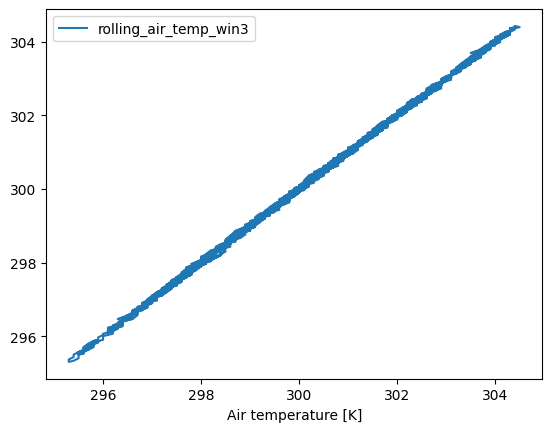

In [6]:
line_plot=df.plot.line(x='Air temperature [K]',y='rolling_air_temp_win3')   

In [7]:
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000


In [8]:
df['rolling_air_temp_win5']=df['Air temperature [K]'].rolling(window=5).mean()
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22


#Observation of Rolling mean

The rolling mean was calculated using window sizes of 3 and 5 of the Air temperature feature. The rolling mean values were found to be very close to the originl temperature values, indicating that there are no sudden fluctuations in air temperature. Most values remain within a narrow range around the overall mean temperature, suggesting that the environmental conditions are relativey stable throughout the dataset

In [9]:
df['rolling_air_temp_variance_win3']=df['Air temperature [K]'].rolling(window=3).var()
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16,0.003333
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14,0.003333
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14,0.000000
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16,0.013333
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22,0.040000


<Axes: >

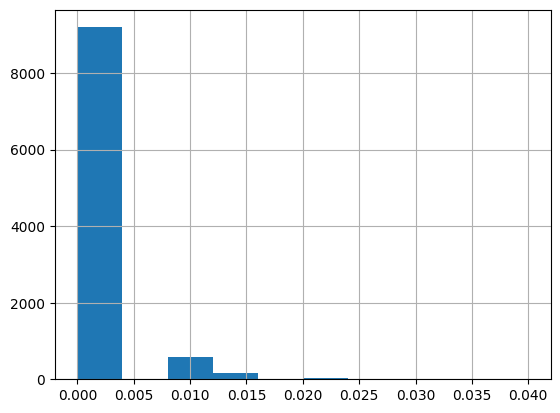

In [10]:
df['rolling_air_temp_variance_win3'].hist()

In [11]:
df['rolling_air_temp_variance_win5']=df['Air temperature [K]'].rolling(window=5).var()
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16,0.003333,0.003
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14,0.003333,0.003
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14,0.000000,0.003
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16,0.013333,0.008
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22,0.040000,0.032


#Observation of rolling variance analysis

The rolling variance was calculated using the window sized of 3 and 5 to measure short term temperature fluctuations. The histogram of the rolling variance shows that the majority of the observations falls within the range of 0.000 to 0.004. This indicates that the variation in air temperature is very loew of most obervations. 
Only a small number of observation exhibit higher variance values , which suggests occasional fluctuations in temperature. However, these occurrences are infrequent compared to overall dataset.

In [12]:
df['Rotational speed [rpm]_win=3']=df['Rotational speed [rpm]'].rolling(window=3).mean()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5,Rotational speed [rpm]_win=3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN,1485.666667
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN,1446.333333
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003,1446.333333


In [13]:
df['Rotational speed [rpm]_win=3'].describe()

count    9998.000000
mean     1538.786591
std       104.692047
min      1306.666667
25%      1467.333333
50%      1522.333333
75%      1591.333333
max      2111.000000
Name: Rotational speed [rpm]_win=3, dtype: float64

In [14]:
df['Rotational speed [rpm]_var_win=3']=df['Rotational speed [rpm]'].rolling(window=3).var()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5,Rotational speed [rpm]_win=3,Rotational speed [rpm]_var_win=3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN,1485.666667,5226.333333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN,1446.333333,2158.333333
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003,1446.333333,2158.333333


In [15]:
df['Rotational speed [rpm]_var_win=3'].describe()

count      9998.000000
mean      31778.134260
std       59707.897258
min           5.333333
25%        5239.333333
50%       13820.666667
75%       33321.333333
max      714154.333333
Name: Rotational speed [rpm]_var_win=3, dtype: float64

<Axes: xlabel='Rotational speed [rpm]', ylabel='Rotational speed [rpm]_var_win=3'>

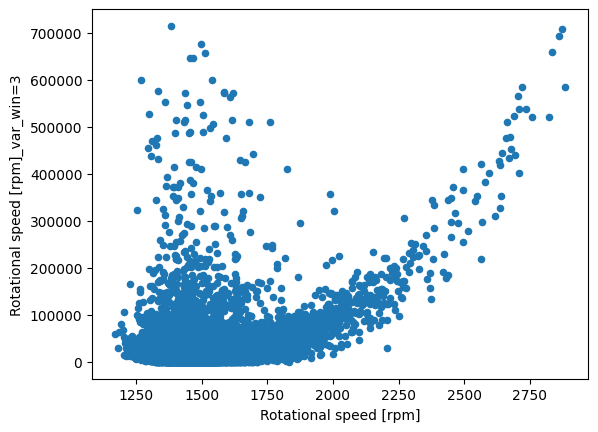

In [16]:
df.plot.scatter(y='Rotational speed [rpm]_var_win=3', x='Rotational speed [rpm]')

In [17]:
df['rolling_Torque [Nm]_win=3']=df['Torque [Nm]'].rolling(window=3).mean()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5,Rotational speed [rpm]_win=3,Rotational speed [rpm]_var_win=3,rolling_Torque [Nm]_win=3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN,1485.666667,5226.333333,46.166667
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN,1446.333333,2158.333333,45.066667
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003,1446.333333,2158.333333,42.966667


In [18]:
df['rolling_Torque [Nm]_win=3'].describe()

count    9998.000000
mean       39.986214
std         5.824052
min        19.833333
25%        36.100000
50%        39.966667
75%        43.933333
max        60.900000
Name: rolling_Torque [Nm]_win=3, dtype: float64

In [19]:
df['rolling_Torque [Nm]_var_win=3']=df['Torque [Nm]'].rolling(window=3).var()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5,Rotational speed [rpm]_win=3,Rotational speed [rpm]_var_win=3,rolling_Torque [Nm]_win=3,rolling_Torque [Nm]_var_win=3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN,1485.666667,5226.333333,46.166667,10.903333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN,1446.333333,2158.333333,45.066667,25.643333
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003,1446.333333,2158.333333,42.966667,31.103333


In [20]:
df['rolling_Torque [Nm]_var_win=3'].describe()

count    9998.000000
mean       98.203673
std        99.859029
min         0.000000
25%        27.013333
50%        67.233333
75%       136.090000
max       925.563333
Name: rolling_Torque [Nm]_var_win=3, dtype: float64

<Axes: xlabel='Torque [Nm]', ylabel='rolling_Torque [Nm]_var_win=3'>

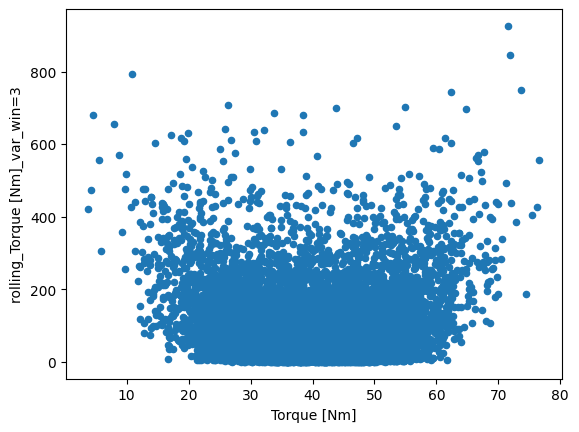

In [21]:
df.plot.scatter(y='rolling_Torque [Nm]_var_win=3', x='Torque [Nm]')

#Overall Observation of features

Initial exploratory analysis of the predictive maintenance dataset shows that the rolling mean for both rotational speed and torque remains relatively stable, indicating consistent short-term operating behavior.

However, the variance measures especially during higher operational ranges shows  occasional spikes and outliers, suggesting intermittent instability in machine performance.

In contrast, air and process temperatures remain relatively stable across observations, indicating that they may not be the primary drivers of short-term anomalies compared to mechanical variables such as torque and rotational speed.

In [22]:
df['temp_dif']=df['Process temperature [K]']-df['Air temperature [K]']

In [23]:
df['temp_dif'].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: temp_dif, dtype: float64

<Axes: >

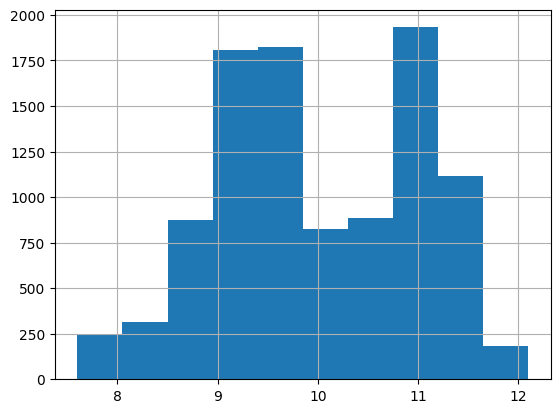

In [24]:
df['temp_dif'].hist(bins=10)

In [25]:
df['Speed_torque_ratio']=df["Rotational speed [rpm]"]/df["Torque [Nm]"]


In [26]:
df["Rotational speed [rpm]"].describe()

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: Rotational speed [rpm], dtype: float64

In [27]:
df['Speed_torque_ratio'].describe()

count    10000.000000
mean        43.167216
std         25.053907
min         15.665796
25%         30.482987
50%         37.403704
75%         48.449457
max        759.473684
Name: Speed_torque_ratio, dtype: float64

<Axes: >

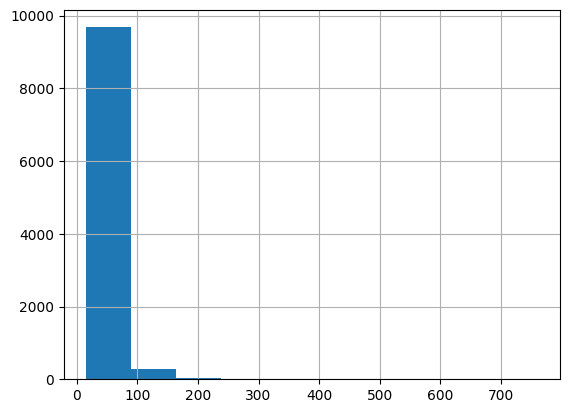

In [28]:
df['Speed_torque_ratio'].hist(bins=10)

In [29]:
df["stress_index"] = (df["Rotational speed [rpm]"] * df["Torque [Nm]"])

In [30]:
df["stress_index"].describe()

count    10000.000000
mean     59967.147040
std      10193.093881
min      10966.800000
25%      53105.400000
50%      59883.900000
75%      66873.750000
max      99980.400000
Name: stress_index, dtype: float64

<Axes: >

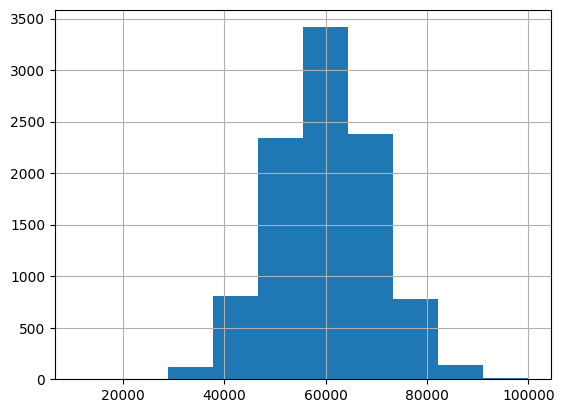

In [31]:
df["stress_index"].hist(bins=10)